# 基于互相关分析推断交通流方向（单日版）

## 核心思路

### 先验条件
- 每条高速公路 (Fwy, Dir) 上的站点顺序已知（按 Abs_PM 排序）
- 但不知道流量的流向（Abs_PM 递增方向是上游还是下游）
- 对于 ML 站点，每条 (Fwy, Dir) 就是一条线性链

### 方法
- 对于线性链上的任意两个站点，通过互相关判断上下游关系
- 理论上：同一链上任意两点的判断结果应该一致
- 按不同距离范围分组，分析准确率随距离的变化

### Ground Truth
- N/E 方向：Abs_PM 递增方向 = 车辆流向（source=小PM, target=大PM）
- S/W 方向：Abs_PM 递减方向 = 车辆流向（source=大PM, target=小PM）

## 1. 环境配置

In [1]:
import pandas as pd
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt
import os
import re
import glob
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ============== 配置区域 ==============
DATA_DIR = "/data/yuzhang_fei/PEMS/PEMSD3_2025"
META_DIR = "../d03_meta"
OUTPUT_DIR = "../output/direction_inference_single_day"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 选择分析日期
TARGET_DATE = "2025_01_15"  # 格式: YYYY_MM_DD

# 互相关参数
METRIC = 'Total_Flow'  # 可选: 'Total_Flow', 'Avg_Speed', 'Avg_Occupancy'
MAX_LAG = 12  # 最大滞后步数 (12步=60分钟)

# 距离范围定义 (英里)
DISTANCE_BINS = [
    (0, 1, '0-1mi'),
    (1, 2, '1-2mi'),
    (2, 5, '2-5mi'),
    (5, 10, '5-10mi'),
    (10, 20, '10-20mi'),
    (20, 50, '20-50mi'),
    (50, 999, '>50mi'),
]

print("库加载完成！")

库加载完成！


## 2. 加载数据（单日交通数据 + 对应日期的元数据）

In [2]:
# ============== 查找元数据文件 ==============

def find_nearest_meta_file(meta_folder, target_date_str):
    """查找 <= 目标日期的最近元数据文件"""
    target_date = datetime.strptime(target_date_str, '%Y_%m_%d')
    meta_files = glob.glob(os.path.join(meta_folder, "d*_text_meta_*.txt"))
    
    if not meta_files:
        return None, None
    
    file_dates = []
    for f in meta_files:
        match = re.search(r'(\d{4})_(\d{2})_(\d{2})', os.path.basename(f))
        if match:
            file_date = datetime(int(match.group(1)), int(match.group(2)), int(match.group(3)))
            file_dates.append((file_date, f))
    
    if not file_dates:
        return None, None
    
    valid_files = [(d, f) for d, f in file_dates if d <= target_date]
    if valid_files:
        return max(valid_files, key=lambda x: x[0])
    else:
        return min(file_dates, key=lambda x: x[0])


# 查找文件
data_file = os.path.join(DATA_DIR, f"d03_text_station_5min_{TARGET_DATE}.txt")
meta_date, meta_file = find_nearest_meta_file(META_DIR, TARGET_DATE)

print(f"数据文件: {data_file}")
print(f"  存在: {os.path.exists(data_file)}")
print(f"元数据文件: {meta_file}")
print(f"  元数据日期: {meta_date.strftime('%Y-%m-%d') if meta_date else 'N/A'}")

数据文件: /data/yuzhang_fei/PEMS/PEMSD3_2025/d03_text_station_5min_2025_01_15.txt
  存在: True
元数据文件: ../d03_meta/d03_text_meta_2024_11_27.txt
  元数据日期: 2024-11-27


In [3]:
# ============== 加载元数据 ==============
META_COLUMNS = [
    'ID', 'Fwy', 'Dir', 'District', 'County', 'City',
    'State_PM', 'Abs_PM', 'Latitude', 'Longitude', 'Length',
    'Type', 'Lanes', 'Name', 'User_ID_1', 'User_ID_2',
    'User_ID_3', 'User_ID_4'
]

meta_df = pd.read_csv(
    meta_file, sep='\t', names=META_COLUMNS, header=0,
    dtype={'ID': str, 'Fwy': str}
)

# 只保留 ML 站点
ml_meta = meta_df[meta_df['Type'] == 'ML'].copy()
print(f"总站点数: {len(meta_df)}")
print(f"ML 站点数: {len(ml_meta)}")
print(f"高速公路-方向组合数: {ml_meta.groupby(['Fwy', 'Dir']).ngroups}")

总站点数: 1859
ML 站点数: 871
高速公路-方向组合数: 40


In [4]:
# ============== 加载单日交通数据 ==============
MAX_LANES = 8

BASE_COLUMNS = [
    'Timestamp', 'Station', 'District', 'Freeway', 'Direction',
    'Lane_Type', 'Station_Length', 'Samples', 'Pct_Observed',
    'Total_Flow', 'Avg_Occupancy', 'Avg_Speed'
]

LANE_COLUMNS = []
for i in range(1, MAX_LANES + 1):
    LANE_COLUMNS.extend([
        f'Lane{i}_Samples', f'Lane{i}_Flow',
        f'Lane{i}_Avg_Occ', f'Lane{i}_Avg_Speed', f'Lane{i}_Observed'
    ])

ALL_COLUMNS = BASE_COLUMNS + LANE_COLUMNS

print(f"加载交通数据: {TARGET_DATE}...")
flow_df = pd.read_csv(
    data_file, header=None, names=ALL_COLUMNS,
    dtype={'Station': str}, low_memory=False
)
flow_df['Timestamp'] = pd.to_datetime(flow_df['Timestamp'], format='%m/%d/%Y %H:%M:%S')

# 只保留 ML 站点的数据
ml_ids = set(ml_meta['ID'])
flow_ml = flow_df[flow_df['Station'].isin(ml_ids)].copy()
flow_ml['TimeSlot'] = flow_ml['Timestamp'].dt.hour * 12 + flow_ml['Timestamp'].dt.minute // 5

print(f"总记录数: {len(flow_df):,}")
print(f"ML 记录数: {len(flow_ml):,}")
print(f"ML 站点数 (有数据): {flow_ml['Station'].nunique()}")

加载交通数据: 2025_01_15...
总记录数: 535,392
ML 记录数: 250,848
ML 站点数 (有数据): 871


## 3. 构建传感器对（按距离范围）

In [5]:
def build_pairs_by_distance(ml_meta, distance_bins, stations_with_data=None):
    """
    构建同一 (Fwy, Dir) 链上的传感器对，按距离范围分组。
    
    不限于相邻站点，而是在距离范围内的所有点对。
    
    Ground Truth:
    - N/E: Abs_PM 递增方向 = 车辆流向 → source=小PM, target=大PM
    - S/W: Abs_PM 递减方向 = 车辆流向 → source=大PM, target=小PM
    """
    all_pairs = []
    
    for (fwy, direction), group in ml_meta.groupby(['Fwy', 'Dir']):
        sorted_group = group.sort_values('Abs_PM').reset_index(drop=True)
        n = len(sorted_group)
        
        if n < 2:
            continue
        
        # 对链上的所有点对
        for i in range(n):
            for j in range(i + 1, n):
                node_i = sorted_group.iloc[i]
                node_j = sorted_group.iloc[j]
                
                # 跳过没有数据的站点
                if stations_with_data is not None:
                    if node_i['ID'] not in stations_with_data or node_j['ID'] not in stations_with_data:
                        continue
                
                distance = abs(node_j['Abs_PM'] - node_i['Abs_PM'])
                
                # 确定属于哪个距离范围
                dist_label = None
                for lo, hi, label in distance_bins:
                    if lo <= distance < hi:
                        dist_label = label
                        break
                
                if dist_label is None:
                    continue
                
                # Node1 始终是 Abs_PM 较小的
                # Ground truth 方向
                if direction in ['N', 'E']:
                    # N/E: 车辆沿 Abs_PM 递增方向行驶
                    true_source = node_i['ID']  # 小PM = 上游
                    true_target = node_j['ID']  # 大PM = 下游
                else:
                    # S/W: 车辆沿 Abs_PM 递减方向行驶
                    true_source = node_j['ID']  # 大PM = 上游
                    true_target = node_i['ID']  # 小PM = 下游
                
                all_pairs.append({
                    'Node1': node_i['ID'],
                    'Node2': node_j['ID'],
                    'Node1_PM': node_i['Abs_PM'],
                    'Node2_PM': node_j['Abs_PM'],
                    'Fwy': fwy,
                    'Dir': direction,
                    'Distance': distance,
                    'Dist_Bin': dist_label,
                    'True_Source': true_source,
                    'True_Target': true_target,
                    'Is_Adjacent': (j == i + 1),
                })
    
    return pd.DataFrame(all_pairs)


# 有数据的站点集合
stations_with_data = set(flow_ml['Station'].unique())
print(f"有数据的 ML 站点: {len(stations_with_data)}")

# 构建传感器对
pairs_df = build_pairs_by_distance(ml_meta, DISTANCE_BINS, stations_with_data)
print(f"\n总传感器对数: {len(pairs_df):,}")

# 按距离范围统计
print(f"\n按距离范围统计:")
for label in [b[2] for b in DISTANCE_BINS]:
    count = (pairs_df['Dist_Bin'] == label).sum()
    adj_count = ((pairs_df['Dist_Bin'] == label) & pairs_df['Is_Adjacent']).sum()
    if count > 0:
        print(f"  {label:>10s}: {count:>6,} 对 (其中相邻: {adj_count:>4,})")

有数据的 ML 站点: 871

总传感器对数: 31,186

按距离范围统计:
       0-1mi:  1,071 对 (其中相邻:  571)
       1-2mi:  1,150 对 (其中相邻:  109)
       2-5mi:  3,293 对 (其中相邻:   85)
      5-10mi:  4,656 对 (其中相邻:   30)
     10-20mi:  6,425 对 (其中相邻:   21)
     20-50mi:  7,144 对 (其中相邻:   15)
       >50mi:  7,447 对 (其中相邻:    0)


## 4. 构建序列缓存 & 互相关计算

In [6]:
def build_series_cache_single_day(flow_ml, stations, metric):
    """
    构建单日序列缓存
    返回: {station_id: np.array(288)} 
    """
    df = flow_ml[flow_ml['Station'].isin(stations)][['Station', 'TimeSlot', metric]].copy()
    
    if df.empty:
        return {}
    
    pivot = df.pivot_table(
        index='Station', columns='TimeSlot',
        values=metric, aggfunc='first'
    )
    pivot = pivot.reindex(columns=np.arange(288))
    
    cache = {}
    for station, row in pivot.iterrows():
        cache[station] = row.values.astype(float)
    return cache


def compute_lag(series1, series2, max_lag=12):
    """
    计算两个序列的互相关最优滞后
    
    返回:
    - lag: 最优滞后（正值 = series1 领先 = series1 是上游）
    - corr: 最大相关系数
    """
    if series1 is None or series2 is None:
        return np.nan, np.nan
    
    mask = ~(np.isnan(series1) | np.isnan(series2))
    s1 = series1[mask]
    s2 = series2[mask]
    
    if len(s1) < 50:
        return np.nan, np.nan
    if np.std(s1) < 1e-6 or np.std(s2) < 1e-6:
        return np.nan, np.nan
    
    s1 = (s1 - np.mean(s1)) / np.std(s1)
    s2 = (s2 - np.mean(s2)) / np.std(s2)
    
    correlation = signal.correlate(s2, s1, mode='full')
    lags = signal.correlation_lags(len(s2), len(s1), mode='full')
    
    valid_mask = (lags >= -max_lag) & (lags <= max_lag)
    correlation = correlation[valid_mask]
    lags = lags[valid_mask]
    correlation = correlation / len(s1)
    
    max_idx = np.argmax(np.abs(correlation))
    best_lag = lags[max_idx]
    best_corr = correlation[max_idx]
    
    return best_lag, best_corr


# 构建缓存
all_stations = set(pairs_df['Node1'].unique()) | set(pairs_df['Node2'].unique())
print(f"需要缓存的站点数: {len(all_stations)}")

series_cache = build_series_cache_single_day(flow_ml, all_stations, METRIC)
print(f"成功缓存的站点数: {len(series_cache)}")

需要缓存的站点数: 866
成功缓存的站点数: 866


## 5. 批量分析所有点对

In [7]:
print(f"开始分析 {len(pairs_df):,} 个点对...")
print(f"指标: {METRIC}, 最大滞后: {MAX_LAG} 步 ({MAX_LAG*5} 分钟)")
print("="*60)

results = []
total = len(pairs_df)

for idx, row in enumerate(pairs_df.itertuples(index=False), 1):
    s1 = series_cache.get(row.Node1)
    s2 = series_cache.get(row.Node2)
    
    lag, corr = compute_lag(s1, s2, MAX_LAG)
    
    # 判断方向
    if np.isnan(lag):
        pred_source = 'unknown'
    elif lag > 0:
        pred_source = row.Node1  # Node1 领先 = Node1 是上游
    elif lag < 0:
        pred_source = row.Node2  # Node2 领先 = Node2 是上游
    else:
        pred_source = 'uncertain'  # lag=0, 无法判断
    
    results.append({
        'Node1': row.Node1,
        'Node2': row.Node2,
        'Node1_PM': row.Node1_PM,
        'Node2_PM': row.Node2_PM,
        'Fwy': row.Fwy,
        'Dir': row.Dir,
        'Distance': row.Distance,
        'Dist_Bin': row.Dist_Bin,
        'Is_Adjacent': row.Is_Adjacent,
        'True_Source': row.True_Source,
        'Pred_Source': pred_source,
        'Lag': lag,
        'Corr': corr,
    })
    
    if idx % 2000 == 0 or idx == total:
        print(f"已处理 {idx:,}/{total:,} ({idx/total*100:.1f}%)")

results_df = pd.DataFrame(results)
results_df['Correct'] = results_df['Pred_Source'] == results_df['True_Source']

print(f"\n分析完成！结果: {len(results_df):,} 行")

开始分析 31,186 个点对...
指标: Total_Flow, 最大滞后: 12 步 (60 分钟)
已处理 2,000/31,186 (6.4%)
已处理 4,000/31,186 (12.8%)
已处理 6,000/31,186 (19.2%)
已处理 8,000/31,186 (25.7%)
已处理 10,000/31,186 (32.1%)
已处理 12,000/31,186 (38.5%)
已处理 14,000/31,186 (44.9%)
已处理 16,000/31,186 (51.3%)
已处理 18,000/31,186 (57.7%)
已处理 20,000/31,186 (64.1%)
已处理 22,000/31,186 (70.5%)
已处理 24,000/31,186 (77.0%)
已处理 26,000/31,186 (83.4%)
已处理 28,000/31,186 (89.8%)
已处理 30,000/31,186 (96.2%)
已处理 31,186/31,186 (100.0%)

分析完成！结果: 31,186 行


## 6. 精度评估

In [8]:
# 总体统计
total = len(results_df)
unknown = (results_df['Pred_Source'] == 'unknown').sum()
uncertain = (results_df['Pred_Source'] == 'uncertain').sum()
valid = results_df[~results_df['Pred_Source'].isin(['unknown', 'uncertain'])]
correct = valid['Correct'].sum()

print("="*60)
print(f"方向推断精度评估 (日期: {TARGET_DATE})")
print("="*60)
print(f"总点对数:    {total:,}")
print(f"有效预测:    {len(valid):,} ({len(valid)/total*100:.1f}%)")
print(f"不确定(lag=0): {uncertain:,} ({uncertain/total*100:.1f}%)")
print(f"无数据:      {unknown:,} ({unknown/total*100:.1f}%)")
print(f"")
print(f"正确预测:    {correct:,}")
if len(valid) > 0:
    print(f"有效预测精度: {correct/len(valid)*100:.1f}%")

方向推断精度评估 (日期: 2025_01_15)
总点对数:    31,186
有效预测:    11,797 (37.8%)
不确定(lag=0): 19,389 (62.2%)
无数据:      0 (0.0%)

正确预测:    6,250
有效预测精度: 53.0%


In [9]:
# 按距离范围统计精度
print("\n" + "="*60)
print("按距离范围统计精度")
print("="*60)

dist_stats = []

for lo, hi, label in DISTANCE_BINS:
    subset = results_df[results_df['Dist_Bin'] == label]
    if len(subset) == 0:
        continue
    
    valid_sub = subset[~subset['Pred_Source'].isin(['unknown', 'uncertain'])]
    
    n_total = len(subset)
    n_valid = len(valid_sub)
    n_correct = valid_sub['Correct'].sum() if n_valid > 0 else 0
    n_uncertain = (subset['Pred_Source'] == 'uncertain').sum()
    n_unknown = (subset['Pred_Source'] == 'unknown').sum()
    accuracy = n_correct / n_valid * 100 if n_valid > 0 else 0
    
    dist_stats.append({
        'Dist_Bin': label,
        'Total': n_total,
        'Valid': n_valid,
        'Correct': n_correct,
        'Uncertain': n_uncertain,
        'Unknown': n_unknown,
        'Accuracy(%)': accuracy,
    })

dist_stats_df = pd.DataFrame(dist_stats)
display(dist_stats_df)


按距离范围统计精度


,Dist_Bin,Total,Valid,Correct,Uncertain,Unknown,Accuracy(%)
0,0-1mi,1071,104,57,967,0,54.807692
1,1-2mi,1150,178,124,972,0,69.662921
2,2-5mi,3293,821,578,2472,0,70.401949
3,5-10mi,4656,1498,1090,3158,0,72.763685
4,10-20mi,6425,1893,1178,4532,0,62.229266
5,20-50mi,7144,2957,1525,4187,0,51.572540
6,>50mi,7447,4346,1698,3101,0,39.070410


In [10]:
# 只看相邻点对 vs 非相邻点对
print("\n" + "="*60)
print("相邻 vs 非相邻点对精度")
print("="*60)

for is_adj, label in [(True, '相邻'), (False, '非相邻')]:
    subset = results_df[results_df['Is_Adjacent'] == is_adj]
    valid_sub = subset[~subset['Pred_Source'].isin(['unknown', 'uncertain'])]
    if len(valid_sub) > 0:
        acc = valid_sub['Correct'].sum() / len(valid_sub) * 100
        print(f"  {label}: {len(valid_sub):,} 有效对, 精度 {acc:.1f}%")
    else:
        print(f"  {label}: 无有效对")


相邻 vs 非相邻点对精度
  相邻: 155 有效对, 精度 65.8%
  非相邻: 11,642 有效对, 精度 52.8%


In [11]:
# 按方向统计精度
print("\n" + "="*60)
print("按方向统计")
print("="*60)

for direction in ['N', 'S', 'E', 'W']:
    subset = results_df[results_df['Dir'] == direction]
    valid_sub = subset[~subset['Pred_Source'].isin(['unknown', 'uncertain'])]
    if len(valid_sub) > 0:
        acc = valid_sub['Correct'].sum() / len(valid_sub) * 100
        print(f"  {direction}: {len(valid_sub):,} 有效对, 精度 {acc:.1f}%")


按方向统计
  N: 1,970 有效对, 精度 72.1%
  S: 2,866 有效对, 精度 68.3%
  E: 3,550 有效对, 精度 44.9%
  W: 3,411 有效对, 精度 37.5%


In [12]:
# 按高速公路统计（检测哪些高速的方向推断最可靠）
print("\n" + "="*60)
print("按高速公路统计精度")
print("="*60)

fwy_stats = []
for (fwy, direction), group in results_df.groupby(['Fwy', 'Dir']):
    valid_sub = group[~group['Pred_Source'].isin(['unknown', 'uncertain'])]
    if len(valid_sub) == 0:
        continue
    
    acc = valid_sub['Correct'].sum() / len(valid_sub) * 100
    fwy_stats.append({
        'Fwy': fwy,
        'Dir': direction,
        'Total': len(group),
        'Valid': len(valid_sub),
        'Correct': valid_sub['Correct'].sum(),
        'Accuracy(%)': acc
    })

fwy_stats_df = pd.DataFrame(fwy_stats).sort_values('Accuracy(%)')
print(f"\n精度最低的 10 条:")
display(fwy_stats_df.head(10))
print(f"\n精度最高的 10 条:")
display(fwy_stats_df.tail(10))


按高速公路统计精度

精度最低的 10 条:


,Fwy,Dir,Total,Valid,Correct,Accuracy(%)
2,12,W,10,4,0,0.000000
4,160,S,3,2,0,0.000000
15,49,S,3,2,0,0.000000
14,49,N,3,2,0,0.000000
13,45,N,3,2,0,0.000000
24,70,E,28,18,5,27.777778
8,20,W,55,39,13,33.333333
25,70,W,21,17,6,35.294118
19,50,W,5460,1588,569,35.831234
26,80,E,4950,1562,588,37.644046



精度最高的 10 条:


,Fwy,Dir,Total,Valid,Correct,Accuracy(%)
17,5,S,1378,531,411,77.401130
16,5,N,1540,402,313,77.860697
21,51,S,171,33,27,81.818182
1,113,S,10,8,7,87.500000
12,28,W,3,1,1,100.000000
6,162,W,1,1,1,100.000000
3,160,N,1,1,1,100.000000
10,267,E,1,1,1,100.000000
5,162,E,6,3,3,100.000000
23,65,S,136,11,11,100.000000


## 7. 线性链一致性分析

对于每条 (Fwy, Dir)，链上所有点对的方向应该一致。
如果多数点对投票方向一致，则认为链方向已确定。

In [13]:
print("="*60)
print("线性链一致性分析")
print("="*60)

chain_stats = []

for (fwy, direction), group in results_df.groupby(['Fwy', 'Dir']):
    valid_sub = group[~group['Pred_Source'].isin(['unknown', 'uncertain'])]
    if len(valid_sub) < 2:
        continue
    
    # 对于每个有效预测，判断是否指向 "PM递增" 方向
    # Pred_Source == Node1 (PM小的) → 认为流向=PM递增
    # Pred_Source == Node2 (PM大的) → 认为流向=PM递减
    vote_increasing = (valid_sub['Pred_Source'] == valid_sub['Node1']).sum()
    vote_decreasing = (valid_sub['Pred_Source'] == valid_sub['Node2']).sum()
    total_votes = vote_increasing + vote_decreasing
    
    majority = max(vote_increasing, vote_decreasing)
    consistency = majority / total_votes * 100
    
    # 多数投票方向
    inferred_flow = 'PM_increasing' if vote_increasing > vote_decreasing else 'PM_decreasing'
    
    # Ground truth: N/E → PM_increasing, S/W → PM_decreasing
    true_flow = 'PM_increasing' if direction in ['N', 'E'] else 'PM_decreasing'
    chain_correct = (inferred_flow == true_flow)
    
    chain_stats.append({
        'Fwy': fwy,
        'Dir': direction,
        'N_Pairs': total_votes,
        'Vote_Increasing': vote_increasing,
        'Vote_Decreasing': vote_decreasing,
        'Consistency(%)': consistency,
        'Inferred_Flow': inferred_flow,
        'True_Flow': true_flow,
        'Chain_Correct': chain_correct,
    })

chain_df = pd.DataFrame(chain_stats).sort_values('Consistency(%)', ascending=False)

print(f"\n总链数: {len(chain_df)}")
print(f"方向判断正确的链数: {chain_df['Chain_Correct'].sum()} ({chain_df['Chain_Correct'].mean()*100:.1f}%)")
print(f"平均一致性: {chain_df['Consistency(%)'].mean():.1f}%")

print(f"\n一致性最低的链:")
display(chain_df.tail(10))

print(f"\n方向判断错误的链:")
wrong_chains = chain_df[~chain_df['Chain_Correct']]
display(wrong_chains)

线性链一致性分析

总链数: 28
方向判断正确的链数: 16 (57.1%)
平均一致性: 74.1%

一致性最低的链:


,Fwy,Dir,N_Pairs,Vote_Increasing,Vote_Decreasing,Consistency(%),Inferred_Flow,True_Flow,Chain_Correct
15,50,W,1588,1019,569,64.168766,PM_increasing,PM_decreasing,False
5,20,E,24,15,9,62.500000,PM_increasing,PM_increasing,True
22,80,E,1562,588,974,62.355954,PM_decreasing,PM_increasing,False
23,80,W,1759,1071,688,60.886868,PM_increasing,PM_decreasing,False
24,89,N,34,20,14,58.823529,PM_increasing,PM_increasing,True
0,113,N,7,4,3,57.142857,PM_increasing,PM_increasing,True
25,89,S,37,18,19,51.351351,PM_decreasing,PM_decreasing,True
14,50,E,1940,981,959,50.567010,PM_increasing,PM_increasing,True
8,28,E,2,1,1,50.000000,PM_decreasing,PM_increasing,False
7,244,W,2,1,1,50.000000,PM_decreasing,PM_decreasing,True



方向判断错误的链:


,Fwy,Dir,N_Pairs,Vote_Increasing,Vote_Decreasing,Consistency(%),Inferred_Flow,True_Flow,Chain_Correct
3,160,S,2,2,0,100.000000,PM_increasing,PM_decreasing,False
2,12,W,4,4,0,100.000000,PM_increasing,PM_decreasing,False
11,49,S,2,2,0,100.000000,PM_increasing,PM_decreasing,False
10,49,N,2,0,2,100.000000,PM_decreasing,PM_increasing,False
9,45,N,2,0,2,100.000000,PM_decreasing,PM_increasing,False
20,70,E,18,5,13,72.222222,PM_decreasing,PM_increasing,False
6,20,W,39,26,13,66.666667,PM_increasing,PM_decreasing,False
21,70,W,17,11,6,64.705882,PM_increasing,PM_decreasing,False
15,50,W,1588,1019,569,64.168766,PM_increasing,PM_decreasing,False
22,80,E,1562,588,974,62.355954,PM_decreasing,PM_increasing,False


## 8. 可视化

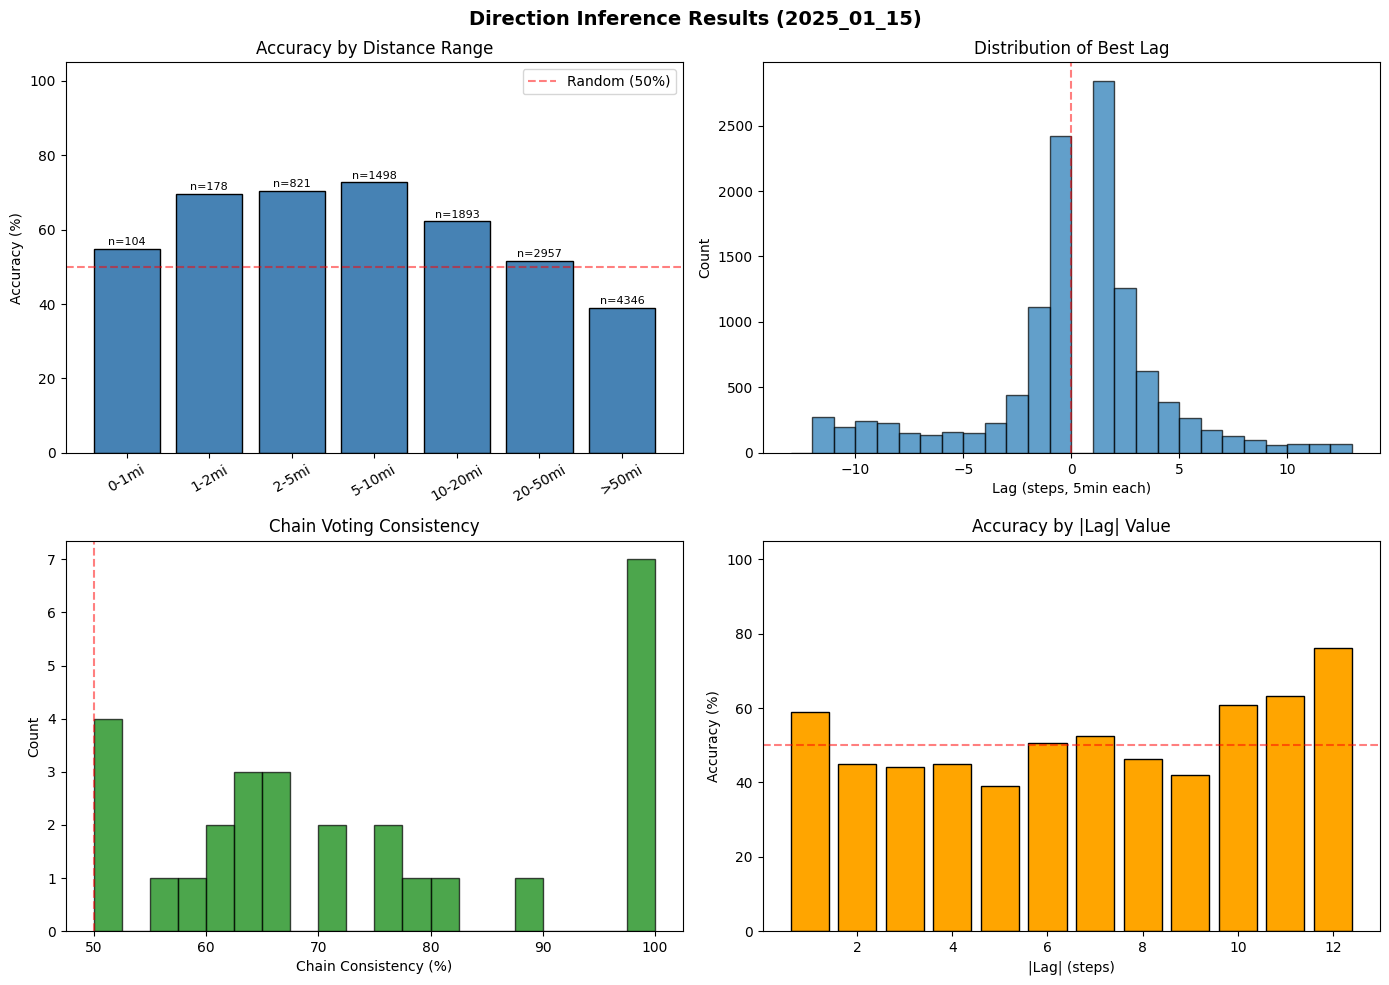

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. 按距离范围的精度
ax = axes[0, 0]
x = range(len(dist_stats_df))
ax.bar(x, dist_stats_df['Accuracy(%)'], color='steelblue', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(dist_stats_df['Dist_Bin'], rotation=30)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy by Distance Range')
ax.set_ylim(0, 105)
ax.axhline(y=50, color='red', linestyle='--', alpha=0.5, label='Random (50%)')
ax.legend()
# 标注数量
for i, row in dist_stats_df.iterrows():
    ax.text(list(x)[i], row['Accuracy(%)'] + 1, f"n={row['Valid']}", ha='center', fontsize=8)

# 2. Lag 分布
ax = axes[0, 1]
valid = results_df[~results_df['Pred_Source'].isin(['unknown', 'uncertain'])]
ax.hist(valid['Lag'], bins=range(-MAX_LAG-1, MAX_LAG+2), edgecolor='black', alpha=0.7)
ax.set_xlabel('Lag (steps, 5min each)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Best Lag')
ax.axvline(x=0, color='red', linestyle='--', alpha=0.5)

# 3. 链一致性分布
ax = axes[1, 0]
ax.hist(chain_df['Consistency(%)'], bins=20, edgecolor='black', alpha=0.7, color='green')
ax.set_xlabel('Chain Consistency (%)')
ax.set_ylabel('Count')
ax.set_title('Chain Voting Consistency')
ax.axvline(x=50, color='red', linestyle='--', alpha=0.5)

# 4. 正确率 vs |Lag|
ax = axes[1, 1]
valid_copy = valid.copy()
valid_copy['Abs_Lag'] = valid_copy['Lag'].abs()
lag_bins = range(0, MAX_LAG + 1)
lag_acc = []
for lag_val in lag_bins:
    subset = valid_copy[valid_copy['Abs_Lag'] == lag_val]
    if len(subset) > 0:
        lag_acc.append(subset['Correct'].mean() * 100)
    else:
        lag_acc.append(np.nan)
ax.bar(lag_bins, lag_acc, color='orange', edgecolor='black')
ax.set_xlabel('|Lag| (steps)')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy by |Lag| Value')
ax.set_ylim(0, 105)
ax.axhline(y=50, color='red', linestyle='--', alpha=0.5)

plt.suptitle(f'Direction Inference Results ({TARGET_DATE})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'direction_inference_{TARGET_DATE}.png'), dpi=150)
plt.show()

## 9. 查看错误案例

In [15]:
# 查看一些具体的错误案例
wrong = results_df[
    (~results_df['Correct']) & 
    (~results_df['Pred_Source'].isin(['uncertain', 'unknown']))
].copy()

print(f"错误预测总数: {len(wrong):,}")
print(f"\n按距离范围:")
print(wrong['Dist_Bin'].value_counts())

print(f"\n错误案例示例 (近距离):")
display(wrong.sort_values('Distance')[
    ['Node1', 'Node2', 'Fwy', 'Dir', 'Distance', 'Dist_Bin',
     'Lag', 'Corr', 'True_Source', 'Pred_Source']
].head(15))

错误预测总数: 5,547

按距离范围:
Dist_Bin
>50mi      2648
20-50mi    1432
10-20mi     715
5-10mi      408
2-5mi       243
1-2mi        54
0-1mi        47
Name: count, dtype: int64

错误案例示例 (近距离):


,Node1,Node2,Fwy,Dir,Distance,Dist_Bin,Lag,Corr,True_Source,Pred_Source
8160,3088032,3088041,50,E,0.000,0-1mi,-1,0.885733,3088032,3088041
31171,3423094,3017022,99,S,0.003,0-1mi,4,0.852185,3017022,3423094
14404,3054055,3054054,50,W,0.006,0-1mi,8,0.422031,3054054,3054055
25285,3032111,3027032,99,N,0.008,0-1mi,-5,0.759273,3032111,3027032
155,3029112,3029113,244,W,0.015,0-1mi,4,0.782993,3029113,3029112
6565,3022031,3900021,50,E,0.067,0-1mi,-1,0.837179,3022031,3900021
6566,3022031,3025083,50,E,0.067,0-1mi,-1,0.840214,3022031,3025083
6567,3022031,3025081,50,E,0.067,0-1mi,-2,0.825230,3022031,3025081
6568,3022031,314042,50,E,0.081,0-1mi,-1,0.844435,3022031,314042
14764,312757,312771,51,S,0.085,0-1mi,1,0.846499,312771,312757


## 10. 保存结果

In [16]:
# 保存完整结果
output_path = os.path.join(OUTPUT_DIR, f'direction_inference_{TARGET_DATE}.csv')
results_df.to_csv(output_path, index=False)
print(f"结果已保存: {output_path}")

# 保存距离精度统计
dist_path = os.path.join(OUTPUT_DIR, f'accuracy_by_distance_{TARGET_DATE}.csv')
dist_stats_df.to_csv(dist_path, index=False)
print(f"距离统计已保存: {dist_path}")

# 保存链一致性统计
chain_path = os.path.join(OUTPUT_DIR, f'chain_consistency_{TARGET_DATE}.csv')
chain_df.to_csv(chain_path, index=False)
print(f"链一致性已保存: {chain_path}")

# 保存汇总报告
report = f"""
方向推断结果报告 (单日版)
{'='*60}

日期: {TARGET_DATE}
指标: {METRIC}
最大滞后: {MAX_LAG} 步 ({MAX_LAG*5} 分钟)

{'='*60}
总体统计
{'='*60}
总点对数: {total:,}
有效预测: {len(valid):,} ({len(valid)/total*100:.1f}%)
有效预测精度: {correct/len(valid)*100:.1f}%

{'='*60}
按距离范围
{'='*60}
{dist_stats_df.to_string(index=False)}

{'='*60}
链一致性
{'='*60}
总链数: {len(chain_df)}
方向正确率: {chain_df['Chain_Correct'].mean()*100:.1f}%
平均一致性: {chain_df['Consistency(%)'].mean():.1f}%
"""

report_path = os.path.join(OUTPUT_DIR, f'direction_inference_report_{TARGET_DATE}.txt')
with open(report_path, 'w') as f:
    f.write(report)
print(f"报告已保存: {report_path}")

结果已保存: ../output/direction_inference_single_day/direction_inference_2025_01_15.csv
距离统计已保存: ../output/direction_inference_single_day/accuracy_by_distance_2025_01_15.csv
链一致性已保存: ../output/direction_inference_single_day/chain_consistency_2025_01_15.csv
报告已保存: ../output/direction_inference_single_day/direction_inference_report_2025_01_15.txt
